## Component sum check — step2_hese_flavor

Four checks:
1. **Astro + Conv + Muon = Total?** — standard components (nosyst) should sum to `MC_nosyst`
2. **Astro vs Astro_3flavor** — same normalization and composition, different physics model.
   `Astro` uses `astro_SPL_no_inel.yaml` (ratio params); `Astro_3flavor` uses
   `astro_SPL_3flavor_no_inel.yaml` (angle params). Any difference reveals whether the
   `flavor_ratios_to_angles` conversion is exact.
3. **NuE + NuMu + NuTau = Astro_3flavor?** — flavor components should sum to `Astro_3flavor`.
   Each flavor uses `total_astro_norm = astro_norm × ratio`, same best-fit `a`/`b` angles.
4. **Gradient issue** — flavor components are nosyst; this section shows the mismatch with
   `MC_syst` and the two-level gradient correction that fixes it.

In [6]:
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

from NNMFit.utilities import load_pickle

GRAPH_DIR = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/step2_hese_flavor/graphs/all_param_2sigma_1D_10steps"

def load(name):
    return load_pickle(os.path.join(GRAPH_DIR, name))

mc_syst  = load("MC_Histogram.pickle")                     # total MC WITH systematics
total    = load("MC_Histogram_nosyst.pickle")              # total MC without systematics
astro    = load("MC_Histogram_Astro_nosyst.pickle")        # ratio model
astro_3f = load("MC_Histogram_Astro_3flavor_nosyst.pickle") # angle model
conv     = load("MC_Histogram_Conv_nosyst.pickle")
muon     = load("MC_Histogram_Muon_nosyst.pickle")
nue      = load("MC_Histogram_Astro_NuE_nosyst.pickle")
numu     = load("MC_Histogram_Astro_NuMu_nosyst.pickle")
nutau    = load("MC_Histogram_Astro_NuTau_nosyst.pickle")

det_configs = list(total["histograms"].keys())
print("Detector configs:", det_configs)

Detector configs: ['IC86_pass2_SnowStorm_FTP_HESE_Cascades', 'IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades', 'IC86_pass2_SnowStorm_FTP_HESE_Tracks']


In [7]:
def ratio_plot(fig_title, det_configs, top_traces, ratio_traces, ratio_ylabel):
    """Generic helper: top panel = stacked stairs, bottom panel = ratio.
    top_traces:   list of (arr_dict, label, color, linewidth, linestyle)
    ratio_traces: list of (numerator_dict, denominator_dict, label, color)
    """
    ncols = len(det_configs)
    fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 6),
                              gridspec_kw={"height_ratios": [3, 1]})
    if ncols == 1:
        axes = [[axes[0]], [axes[1]]]

    for col, dc in enumerate(det_configs):
        ax0, ax1 = axes[0][col], axes[1][col]
        n = None
        for arr_dict, label, color, lw, ls in top_traces:
            arr = arr_dict[dc].ravel()
            n = len(arr)
            bins = np.arange(n + 1)
            ax0.stairs(arr, bins, label=label, color=color, linewidth=lw, linestyle=ls)
        ax0.set_yscale("log")
        ax0.set_ylabel("Count")
        ax0.set_title(dc.split("_")[-1])
        ax0.legend(fontsize=7)

        centers = np.arange(n) + 0.5
        for num_dict, den_dict, label, color in ratio_traces:
            num = num_dict[dc].ravel()
            den = den_dict[dc].ravel()
            ratio = np.where(den > 0, num / den, np.nan)
            ax1.plot(centers, ratio, ".", color=color, markersize=3, label=label)
            max_dev = np.nanmax(np.abs(ratio - 1))
            print(f"{dc} | {label}: max |ratio-1| = {max_dev:.2e}")
        ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
        ax1.set_ylim(0.85, 1.15)
        ax1.set_ylabel(ratio_ylabel)
        ax1.set_xlabel("Flat bin index")
        if len(ratio_traces) > 1:
            ax1.legend(fontsize=7)

    fig.suptitle(fig_title, fontsize=11)
    plt.tight_layout()
    plt.show()

### 1. Astro + Conv + Muon vs Total (nosyst)

IC86_pass2_SnowStorm_FTP_HESE_Cascades | Sum / Total: max |ratio-1| = 1.11e-15
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades | Sum / Total: max |ratio-1| = 9.63e-04
IC86_pass2_SnowStorm_FTP_HESE_Tracks | Sum / Total: max |ratio-1| = 6.66e-16


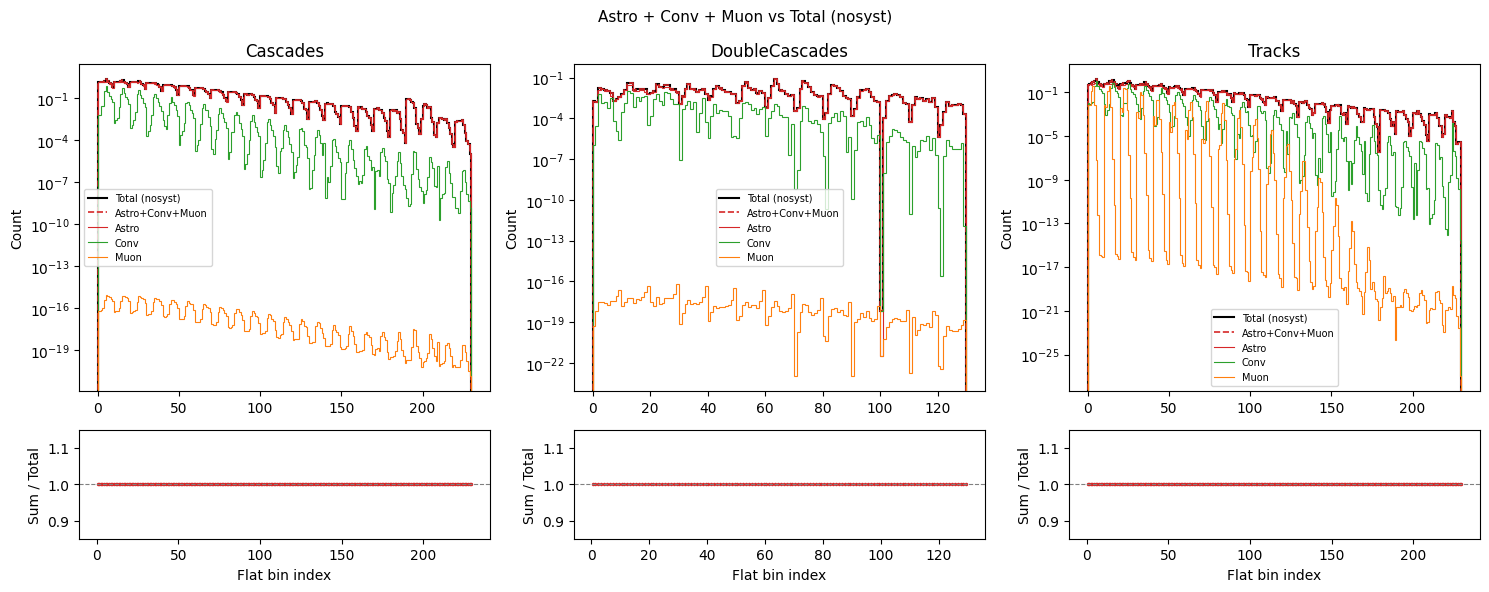

In [8]:
comp_sum_hists = {
    dc: astro["histograms"][dc] + conv["histograms"][dc] + muon["histograms"][dc]
    for dc in det_configs
}
comp_sum = {"histograms": comp_sum_hists}

ratio_plot(
    "Astro + Conv + Muon vs Total (nosyst)",
    det_configs,
    top_traces=[
        (total["histograms"],    "Total (nosyst)",  "black",      1.5, "-"),
        (comp_sum["histograms"], "Astro+Conv+Muon", "tab:red",    1.2, "--"),
        (astro["histograms"],    "Astro",            "tab:red",    0.8, "-"),
        (conv["histograms"],     "Conv",             "tab:green",  0.8, "-"),
        (muon["histograms"],     "Muon",             "tab:orange", 0.8, "-"),
    ],
    ratio_traces=[
        (comp_sum["histograms"], total["histograms"], "Sum / Total", "tab:red"),
    ],
    ratio_ylabel="Sum / Total",
)

### 2. Astro (ratio model) vs Astro_3flavor (angle model)

`Astro` uses `astro_SPL_no_inel.yaml` with the best-fit `astro_nue_ratio` / `astro_nutau_ratio`.
`Astro_3flavor` uses `astro_SPL_3flavor_no_inel.yaml` with `total_astro_norm`, `a`, `b`
derived from those ratios via `flavor_ratios_to_angles`.
If the conversion is exact the ratio should be flat at 1.

IC86_pass2_SnowStorm_FTP_HESE_Cascades | Astro_3flavor / Astro: max |ratio-1| = 4.44e-16
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades | Astro_3flavor / Astro: max |ratio-1| = 6.66e-16
IC86_pass2_SnowStorm_FTP_HESE_Tracks | Astro_3flavor / Astro: max |ratio-1| = 6.66e-16


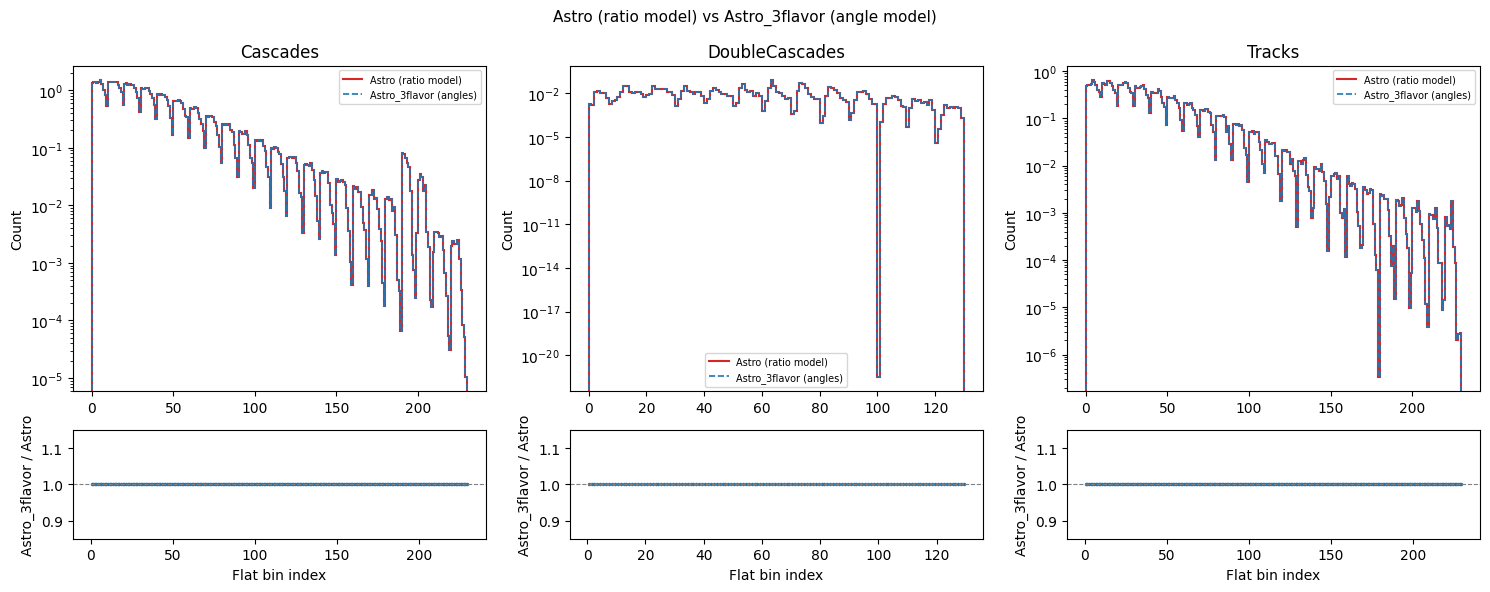

In [9]:
ratio_plot(
    "Astro (ratio model) vs Astro_3flavor (angle model)",
    det_configs,
    top_traces=[
        (astro["histograms"],    "Astro (ratio model)",   "tab:red",  1.5, "-"),
        (astro_3f["histograms"], "Astro_3flavor (angles)", "tab:blue", 1.2, "--"),
    ],
    ratio_traces=[
        (astro_3f["histograms"], astro["histograms"], "Astro_3flavor / Astro", "tab:blue"),
    ],
    ratio_ylabel="Astro_3flavor / Astro",
)

### 3. NuE + NuMu + NuTau vs Astro_3flavor (nosyst)

Flavor components use `astro_SPL_3flavor_no_inel.yaml` with best-fit `a`/`b` and
scaled `total_astro_norm`: NuMu × 1, NuE × nue_ratio, NuTau × nutau_ratio.
Their sum equals `astro_norm × (1 + nue_ratio + nutau_ratio)` = `Astro_3flavor`.

IC86_pass2_SnowStorm_FTP_HESE_Cascades | Sum / Astro_3flavor: max |ratio-1| = 2.44e-15
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades | Sum / Astro_3flavor: max |ratio-1| = 2.00e+00
IC86_pass2_SnowStorm_FTP_HESE_Tracks | Sum / Astro_3flavor: max |ratio-1| = 8.88e-16


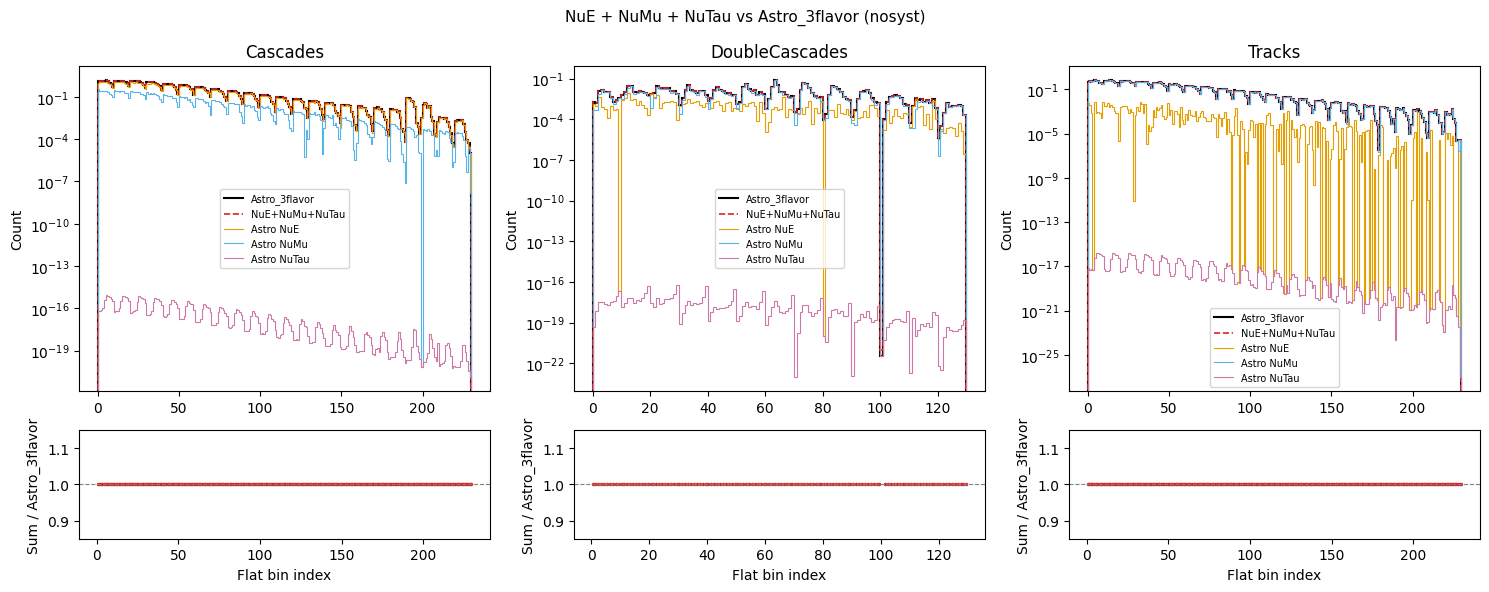

In [10]:
flavor_sum_hists = {
    dc: nue["histograms"][dc] + numu["histograms"][dc] + nutau["histograms"][dc]
    for dc in det_configs
}
flavor_sum = {"histograms": flavor_sum_hists}

ratio_plot(
    "NuE + NuMu + NuTau vs Astro_3flavor (nosyst)",
    det_configs,
    top_traces=[
        (astro_3f["histograms"],    "Astro_3flavor",  "black",   1.5, "-"),
        (flavor_sum["histograms"],  "NuE+NuMu+NuTau", "tab:red", 1.2, "--"),
        (nue["histograms"],         "Astro NuE",       "#E69F00", 0.8, "-"),
        (numu["histograms"],        "Astro NuMu",      "#56B4E9", 0.8, "-"),
        (nutau["histograms"],       "Astro NuTau",     "#CC79A7", 0.8, "-"),
    ],
    ratio_traces=[
        (flavor_sum["histograms"], astro_3f["histograms"], "Sum / Astro_3flavor", "tab:red"),
    ],
    ratio_ylabel="Sum / Astro_3flavor",
)

### 4. Gradient issue: flavor components (nosyst) vs MC total (with syst)

In `plot_functions.py`, `_apply_gradient_to_components` distributes the Snowstorm gradient
only among `COMPONENTS = [Astro, Conv, Muon]`. Flavor components are loaded afterwards as
raw nosyst pickles — they receive the Astro gradient share redistributed among NuE/NuMu/NuTau
weighted by their nosyst rates.

**Step 1** shows the raw discrepancy (no gradient on flavors).
**Step 2** shows the gradient-corrected flavor sum:
- gradient = `MC_syst − MC_nosyst`
- Astro share: `gradient × Astro_nosyst / (Astro_nosyst + Conv_nosyst)`
- Redistributed to NuE/NuMu/NuTau weighted by their nosyst rates
- Conv gets its gradient share; Muon is unchanged

/tmp/ipykernel_1905775/3617816906.py:31: RuntimeWarning: divide by zero encountered in divide
  ratio = np.where(syst > 0, current_sum / syst, np.nan)


IC86_pass2_SnowStorm_FTP_HESE_Cascades: max |ratio-1| (no gradient on flavors) = 2.08e+07
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades: max |ratio-1| (no gradient on flavors) = 2.02e+01
IC86_pass2_SnowStorm_FTP_HESE_Tracks: max |ratio-1| (no gradient on flavors) = 4.87e+01


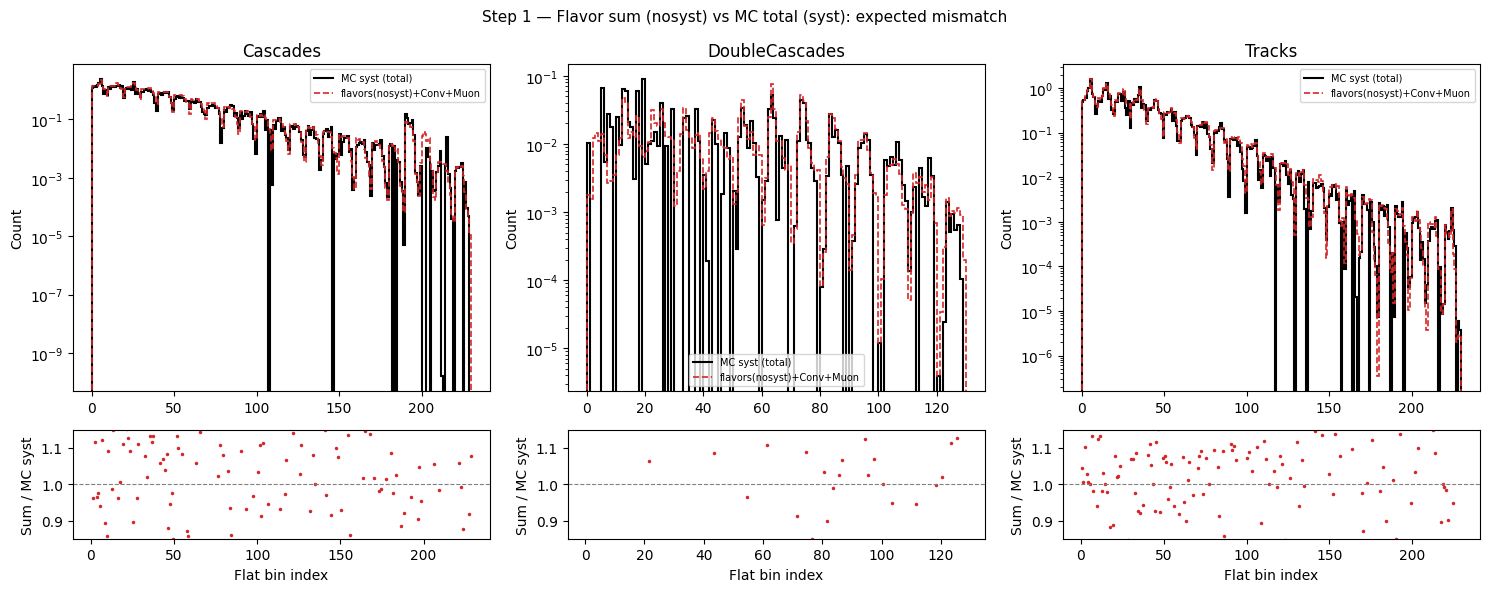

In [11]:
# ---- Step 1: raw nosyst flavor sum vs MC_syst ----
ncols = len(det_configs)
fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 6),
                          gridspec_kw={"height_ratios": [3, 1]})
if ncols == 1:
    axes = [[axes[0]], [axes[1]]]

for col, dc in enumerate(det_configs):
    syst   = mc_syst["histograms"][dc].ravel()
    nosyst = total["histograms"][dc].ravel()
    a_ns   = astro["histograms"][dc].ravel()
    c_ns   = conv["histograms"][dc].ravel()
    m_ns   = muon["histograms"][dc].ravel()
    e_ns   = nue["histograms"][dc].ravel()
    mu_ns  = numu["histograms"][dc].ravel()
    tau_ns = nutau["histograms"][dc].ravel()

    gradient       = syst - nosyst
    non_muon_total = a_ns + c_ns
    conv_corrected = c_ns + np.where(non_muon_total > 0, gradient * c_ns / non_muon_total, 0.0)
    current_sum    = e_ns + mu_ns + tau_ns + conv_corrected + m_ns

    bins    = np.arange(len(syst) + 1)
    centers = np.arange(len(syst)) + 0.5
    ax0, ax1 = axes[0][col], axes[1][col]

    ax0.stairs(syst,        bins, label="MC syst (total)",           color="black",   linewidth=1.5)
    ax0.stairs(current_sum, bins, label="flavors(nosyst)+Conv+Muon", color="tab:red", linewidth=1.2, linestyle="--")
    ax0.set_yscale("log"); ax0.set_ylabel("Count"); ax0.set_title(dc.split("_")[-1]); ax0.legend(fontsize=7)

    ratio = np.where(syst > 0, current_sum / syst, np.nan)
    ax1.plot(centers, ratio, ".", color="tab:red", markersize=3)
    ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
    ax1.set_ylim(0.85, 1.15); ax1.set_ylabel("Sum / MC syst"); ax1.set_xlabel("Flat bin index")
    print(f"{dc}: max |ratio-1| (no gradient on flavors) = {np.nanmax(np.abs(ratio-1)):.2e}")

fig.suptitle("Step 1 — Flavor sum (nosyst) vs MC total (syst): expected mismatch", fontsize=11)
plt.tight_layout(); plt.show()

/tmp/ipykernel_1905775/2192283018.py:42: RuntimeWarning: divide by zero encountered in divide
  ratio = np.where(syst > 0, corrected_sum / syst, np.nan)


IC86_pass2_SnowStorm_FTP_HESE_Cascades: max |ratio-1| (gradient-corrected flavors) = 5.73e-09
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades: max |ratio-1| (gradient-corrected flavors) = 1.75e-14
IC86_pass2_SnowStorm_FTP_HESE_Tracks: max |ratio-1| (gradient-corrected flavors) = 2.64e-14


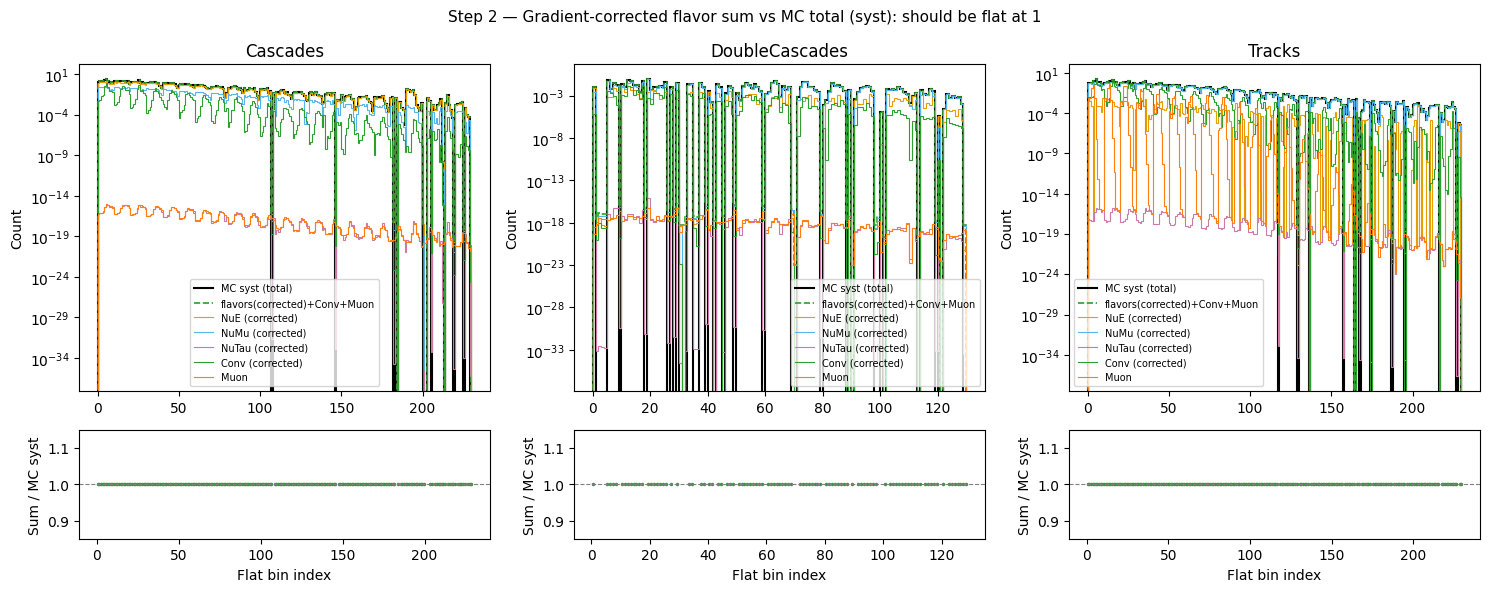

In [12]:
# ---- Step 2: gradient-corrected flavor components ----
fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 6),
                          gridspec_kw={"height_ratios": [3, 1]})
if ncols == 1:
    axes = [[axes[0]], [axes[1]]]

for col, dc in enumerate(det_configs):
    syst   = mc_syst["histograms"][dc].ravel()
    nosyst = total["histograms"][dc].ravel()
    a_ns   = astro["histograms"][dc].ravel()
    c_ns   = conv["histograms"][dc].ravel()
    m_ns   = muon["histograms"][dc].ravel()
    e_ns   = nue["histograms"][dc].ravel()
    mu_ns  = numu["histograms"][dc].ravel()
    tau_ns = nutau["histograms"][dc].ravel()

    gradient        = syst - nosyst
    non_muon_total  = a_ns + c_ns

    astro_grad      = np.where(non_muon_total > 0, gradient * a_ns / non_muon_total, 0.0)
    flavor_total_ns = e_ns + mu_ns + tau_ns
    nue_c   = e_ns   + np.where(flavor_total_ns > 0, astro_grad * e_ns   / flavor_total_ns, 0.0)
    numu_c  = mu_ns  + np.where(flavor_total_ns > 0, astro_grad * mu_ns  / flavor_total_ns, 0.0)
    nutau_c = tau_ns + np.where(flavor_total_ns > 0, astro_grad * tau_ns / flavor_total_ns, 0.0)
    conv_c  = c_ns   + np.where(non_muon_total  > 0, gradient   * c_ns   / non_muon_total,  0.0)

    corrected_sum = nue_c + numu_c + nutau_c + conv_c + m_ns

    bins    = np.arange(len(syst) + 1)
    centers = np.arange(len(syst)) + 0.5
    ax0, ax1 = axes[0][col], axes[1][col]

    ax0.stairs(syst,          bins, label="MC syst (total)",              color="black",      linewidth=1.5)
    ax0.stairs(corrected_sum, bins, label="flavors(corrected)+Conv+Muon", color="tab:green",  linewidth=1.2, linestyle="--")
    ax0.stairs(nue_c,   bins, label="NuE (corrected)",   color="#E69F00",   linewidth=0.8)
    ax0.stairs(numu_c,  bins, label="NuMu (corrected)",  color="#56B4E9",   linewidth=0.8)
    ax0.stairs(nutau_c, bins, label="NuTau (corrected)", color="#CC79A7",   linewidth=0.8)
    ax0.stairs(conv_c,  bins, label="Conv (corrected)",  color="tab:green", linewidth=0.8)
    ax0.stairs(m_ns,    bins, label="Muon",               color="tab:orange",linewidth=0.8)
    ax0.set_yscale("log"); ax0.set_ylabel("Count"); ax0.set_title(dc.split("_")[-1]); ax0.legend(fontsize=7)

    ratio = np.where(syst > 0, corrected_sum / syst, np.nan)
    ax1.plot(centers, ratio, ".", color="tab:green", markersize=3)
    ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
    ax1.set_ylim(0.85, 1.15); ax1.set_ylabel("Sum / MC syst"); ax1.set_xlabel("Flat bin index")
    print(f"{dc}: max |ratio-1| (gradient-corrected flavors) = {np.nanmax(np.abs(ratio-1)):.2e}")

fig.suptitle("Step 2 — Gradient-corrected flavor sum vs MC total (syst): should be flat at 1", fontsize=11)
plt.tight_layout(); plt.show()